# Module 12: Value at Risk (VaR) & Expected Shortfall with EVT

## Historical Simulation and EVT (Cornish-Fisher & POT)

Historical 99% VaR: $174,573.71
Historical 99% ES:  $247,940.23

Cornish-Fisher 99% VaR: $248,223.41
Cornish-Fisher 99% ES:  $377,615.28

Peaks-Over-Threshold 99% ES: $247,512.08


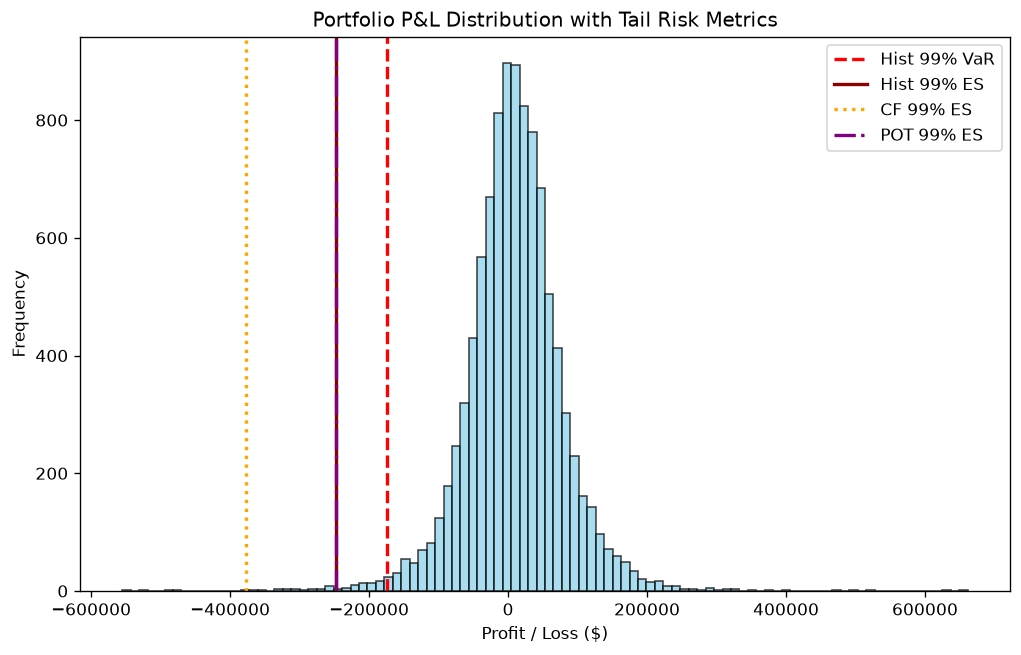

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from src.portfolio.var import historical_var, historical_expected_shortfall
from src.portfolio.var import cornish_fisher_var, cornish_fisher_expected_shortfall
from src.portfolio.var import pot_expected_shortfall
from src.utils.plotting import set_theme

set_theme()

# Generate a synthetic historical P&L vector (fat-tailed distribution using Student-t)
np.random.seed(42)
pnl_historical = np.random.standard_t(df=4, size=10000) * 50000 + 10000

# Calculate Historical VaR & ES at 99% confidence
hist_var = historical_var(pnl_historical, 0.99)
hist_es = historical_expected_shortfall(pnl_historical, 0.99)

# Calculate Cornish-Fisher VaR & ES
cf_var = cornish_fisher_var(pnl_historical, 0.99)
cf_es = cornish_fisher_expected_shortfall(pnl_historical, 0.99)

# Calculate POT EVT Expected Shortfall
pot_es = pot_expected_shortfall(pnl_historical, 0.99)

print(f"Historical 99% VaR: ${hist_var:,.2f}")
print(f"Historical 99% ES:  ${hist_es:,.2f}\n")
print(f"Cornish-Fisher 99% VaR: ${cf_var:,.2f}")
print(f"Cornish-Fisher 99% ES:  ${cf_es:,.2f}\n")
print(f"Peaks-Over-Threshold 99% ES: ${pot_es:,.2f}")

# Plotting the P&L distribution
plt.figure(figsize=(10, 6))
plt.hist(pnl_historical, bins=100, color="skyblue", edgecolor="black", alpha=0.7)
plt.axvline(
    -hist_var, color="red", linestyle="dashed", linewidth=2, label=f"Hist 99% VaR"
)
plt.axvline(
    -hist_es, color="darkred", linestyle="solid", linewidth=2, label=f"Hist 99% ES"
)
plt.axvline(-cf_es, color="orange", linestyle="dotted", linewidth=2, label=f"CF 99% ES")
plt.axvline(
    -pot_es, color="purple", linestyle="dashdot", linewidth=2, label=f"POT 99% ES"
)

plt.title("Portfolio P&L Distribution with Tail Risk Metrics")
plt.xlabel("Profit / Loss ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Full Revaluation VaR

In [2]:
from src.portfolio.portfolio import Portfolio
from src.portfolio.position import Position
from src.curve.nelson_siegel import NelsonSiegelCurve
from src.instruments.bond import Bond
from src.portfolio.var import full_revaluation_var

# Construct a sample portfolio
portfolio = Portfolio()
bond1 = Bond(face_value=100, coupon_rate=0.05, maturity=5.0, freq=2)
bond2 = Bond(face_value=100, coupon_rate=0.03, maturity=10.0, freq=2)
portfolio.add_position(Position(bond=bond1, quantity=10000))
portfolio.add_position(Position(bond=bond2, quantity=5000))

base_curve = NelsonSiegelCurve(beta0=0.04, beta1=-0.02, beta2=0.02, tau=1.5)

# Generate a grid of historical parallel shifts (in absolute terms, e.g., normally distributed changes)
np.random.seed(42)
yield_shifts = np.random.normal(loc=0.0, scale=0.005, size=500)  # 50 bps daily vol

full_rev_var = full_revaluation_var(
    portfolio, base_curve, yield_shifts, confidence_level=0.99
)

print(f"Full Revaluation 99% VaR: ${full_rev_var:,.2f}")

Full Revaluation 99% VaR: $89,722.90


## Macro-Scenario & Stress Testing (Module 45)
Applying non-parallel curve shifts and central bank policy shocks.

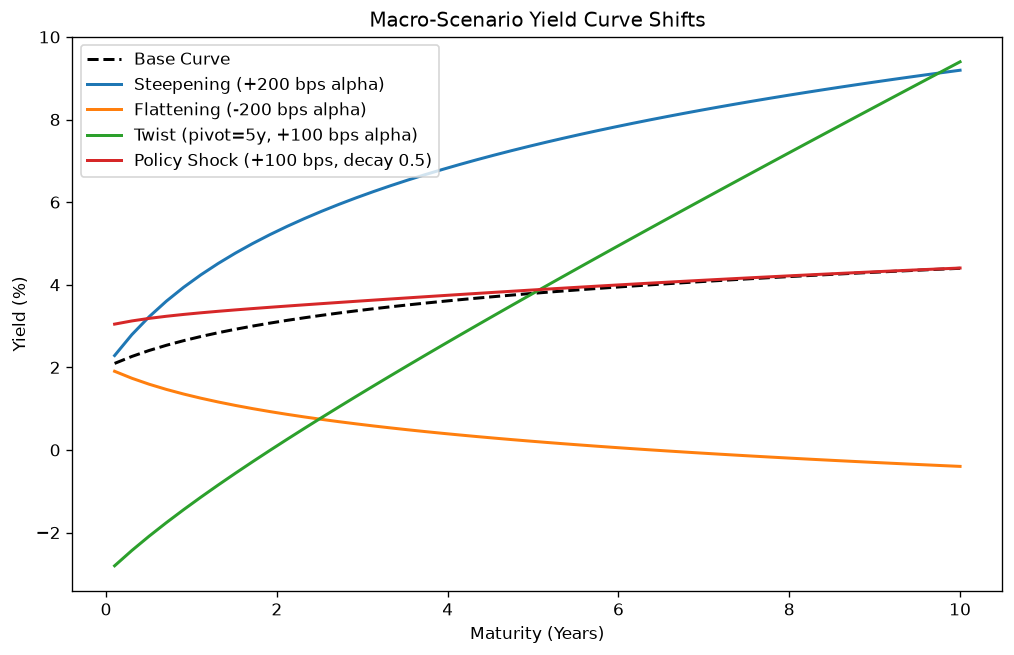

In [3]:
from src.risk.scenario import ScenarioGenerator
import matplotlib.pyplot as plt
import numpy as np
from src.utils.plotting import set_theme

set_theme()

class DummyCurve:
    def __init__(self, tenors, yields):
        self.tenors = np.array(tenors)
        self.yields = np.array(yields)

# Base curve with a normal upward shape
tenors = np.linspace(0.1, 10, 50)
base_yields = 0.02 + 0.01 * np.log(1 + tenors)
base_curve = DummyCurve(tenors, base_yields)

generator = ScenarioGenerator()
steep_curve = generator.apply_non_parallel_shift(base_curve, shift_type='steepening', alpha=0.02)
flat_curve = generator.apply_non_parallel_shift(base_curve, shift_type='flattening', alpha=0.02)
twist_curve = generator.apply_non_parallel_shift(base_curve, shift_type='twist', alpha=0.01, pivot=5)
shock_curve = generator.apply_policy_shock(base_curve, delta_r=0.01, decay=0.5)

plt.figure(figsize=(10, 6))
plt.plot(base_curve.tenors, base_curve.yields * 100, label="Base Curve", color='black', linestyle='--')
plt.plot(steep_curve.tenors, steep_curve.yields * 100, label="Steepening (+200 bps alpha)")
plt.plot(flat_curve.tenors, flat_curve.yields * 100, label="Flattening (-200 bps alpha)")
plt.plot(twist_curve.tenors, twist_curve.yields * 100, label="Twist (pivot=5y, +100 bps alpha)")
plt.plot(shock_curve.tenors, shock_curve.yields * 100, label="Policy Shock (+100 bps, decay 0.5)")
plt.title("Macro-Scenario Yield Curve Shifts")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.legend()
plt.show()